# First Classification 🐥🐥

0. Import usual libraries

In [69]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,f1_score,ConfusionMatrixDisplay,RocCurveDisplay)
import matplotlib.pyplot as plt

1. Download the following data using this link : ```https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Machine+Learning+Supervis%C3%A9/R%C3%A9gression+logistique+Cross+validation/Datasets/ex2data1.txt``` and put it into a DataFrame

Pay attention to the header of the DataFrame, there's something annoying with it! Look at the documentation of `pd.read_csv()` to find a way of solving the problem 🤓

In [10]:
dataset= "https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Machine+Learning+Supervis%C3%A9/R%C3%A9gression+logistique+Cross+validation/Datasets/ex2data1.txt"
df= pd.read_csv(dataset, header=None)


In [11]:
df.head()

,0,1,2
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


2. Rename the columns using the following names : 

"Col_1" / "Col_2" / "Target"

In [13]:
df.columns=["Col_1","Col_2","Target"]
df.head()

,Col_1,Col_2,Target
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


3. Visualize the data as a scatter plot where the two different classes are displayed with different colors.

In [ ]:
import plotly.express as px

fig = px.scatter(df,x="Col_1",y="Col_2",color="Target")
fig.show()


4. Separate X and y into two different objects.

In [25]:
X=df.drop("Target",axis=1)
Y=df["Target"]

print(f"la tables des X: {X}")
print(f"la tables des y: {Y}")

la tables des X:         Col_1      Col_2
0   34.623660  78.024693
1   30.286711  43.894998
2   35.847409  72.902198
3   60.182599  86.308552
4   79.032736  75.344376
..        ...        ...
95  83.489163  48.380286
96  42.261701  87.103851
97  99.315009  68.775409
98  55.340018  64.931938
99  74.775893  89.529813

[100 rows x 2 columns]
la tables des y: 0     0
1     0
2     0
3     1
4     1
     ..
95    1
96    1
97    1
98    1
99    1
Name: Target, Length: 100, dtype: int64


5. Split the data into a train set and a test set

In [49]:
X_train, X_test, Y_train, Y_test = train_test_split(X ,Y ,test_size = 0.2, stratify = Y, random_state = 42)


6. Do you think that the two variables "Col_1" and "Col_2" would be good predictors of the target?

In [39]:
# histogram des X par Y
print("Histogram de Col_1 by Target")
fig = px.histogram(df,x="Col_1",facet_row="Target",color="Target")
fig.show()
print("Histogram de Col_2 by Target")
fig = px.histogram(df,x="Col_2",facet_row="Target",color="Target")
fig.show()

Histogram de Col_1 by Target


Histogram de Col_2 by Target


### Les distributions de Col_1 et Col_2 par target semblent différentes. 

7. Analyze the explanatory variables, what preprocessings are necessary? Make the preprocessings.

In [46]:
desc= df.describe()
print(f"df describe: {desc}")
df.describe()
print("-------------------------------------------")
print("missing data:")
df.isnull().sum()

df describe:             Col_1       Col_2      Target
count  100.000000  100.000000  100.000000
mean    65.644274   66.221998    0.600000
std     19.458222   18.582783    0.492366
min     30.058822   30.603263    0.000000
25%     50.919511   48.179205    0.000000
50%     67.032988   67.682381    1.000000
75%     80.212529   79.360605    1.000000
max     99.827858   98.869436    1.000000
-------------------------------------------
missing data:


Col_1     0
Col_2     0
Target    0
dtype: int64

Some good news:
* There are no missing values in this dataset --> no imputation needed
* Although we're dealing with a classification problem, the _Target_ is alrady encoded as 0s and 1s, so we don't need to use the LabelEncoder
* All the features (_Col1_ and _Col2_) are numeric, so we just want to apply a StandardScaler to the whole array X

In [55]:
# preprocessing
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"X train: {X_train[0:5,:]}")
print("-----------------------------")
print(f"X test: {X_test[0:5,:]}")


X train: [[-0.8284396  -0.77976382]
 [-0.67919821  0.16568501]
 [ 0.4930195   1.04527047]
 [-0.41848617 -0.36865665]
 [ 1.20995678 -0.03006152]]
-----------------------------
X test: [[ 0.46190865  1.24836429]
 [-0.17579369  1.63835015]
 [ 0.67560897  0.48415499]
 [ 0.99548268 -0.50130755]
 [-0.67605684 -0.17399578]]


8. Use the LogisticRegression function from sklearn in order to create a model instance and train it.

In [67]:
rl=LogisticRegression()
rl.fit(X_train,Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

9. What's the accuracy on the train set ? and on the test set ?

Find a way of evaluating the scores without explicitely computing the model's predictions.

In [64]:
print(f"Train accuracy : {rl.score(X_train, Y_train)}")
print(f"Test accuracy : {rl.score(X_test, Y_test)}")

Train accuracy : 0.875
Test accuracy : 0.95


10. What's the average score with a cross-validation using K=10, what's the score's standard deviation?

In [70]:
scores = cross_val_score(rl, X_train, Y_train, cv=10)
avg = scores.mean()
std = scores.std()
print('Cross-validated accuracy : {}\nstandard deviation : {}'.format(avg, std))


Cross-validated accuracy : 0.875
standard deviation : 0.13693063937629152


11. Is the model underfitting/overfitting?

The test accuracy seems a bit higher than the train accuracy, which is usually not possible (it's as if a student who had not learnt his lesson would miraculously get very good results at the final exam 😇)... This doesn't correspond to underfitting nor overfitting 🤔

Actually, the cross-validation shows that the score can typically vary by 
±
0.14
±0.14 just by switching some examples between train and test set. We can conclude that there's no significant difference between the train score and the test score! The model has a good balance between bias and variance, which is as good news!

12. Create objects containing the model's predictions on the train/test sets, as well as the estimated probabilities

In [71]:
# Predictions on training set
print("Predictions on training set...")
Y_train_pred = rl.predict(X_train)
print("...Done.")
print(Y_train_pred[:5])
print()

# It's also possible to get the probabilities estimated by the model:
print("Probabilities on training set...")
Y_train_proba = rl.predict_proba(X_train)
print("...Done.")
print(Y_train_proba[:5])
print()


Predictions on training set...
...Done.
[0 0 1 0 1]

Probabilities on training set...
...Done.
[[0.9091756  0.0908244 ]
 [0.5510213  0.4489787 ]
 [0.01891173 0.98108827]
 [0.65836477 0.34163523]
 [0.03075805 0.96924195]]



In [72]:
# Predictions on test set
print("Predictions on test set...")
Y_test_pred = rl.predict(X_test)
print("...Done.")
print(Y_test_pred[:5])
print()

# It's also possible to get the probabilities estimated by the model:
print("Probabilities on test set...")
Y_test_proba = rl.predict_proba(X_test)
print("...Done.")
print(Y_test_proba[:5])
print()


Predictions on test set...
...Done.
[1 1 1 1 0]

Probabilities on test set...
...Done.
[[0.0138547  0.9861453 ]
 [0.0255437  0.9744563 ]
 [0.03623478 0.96376522]
 [0.1085291  0.8914709 ]
 [0.69803519 0.30196481]]



13. Display the confusion matrix derived from the predictions performed by your model on the training data, do the same on your test data. What do you think of your model's performance, do you think it would generalize well on unknown data?

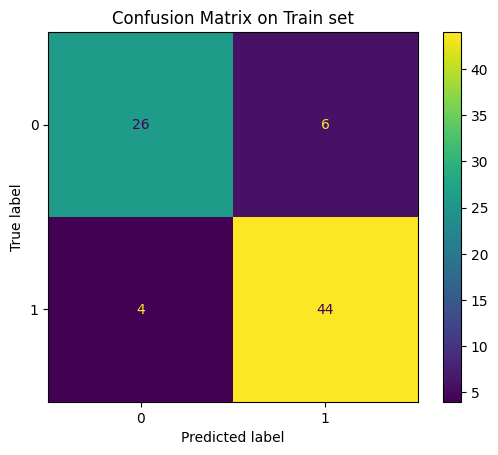

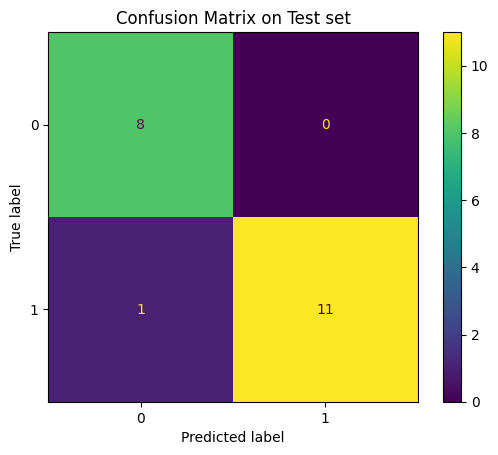

In [73]:
# Visualize confusion matrices
_ , ax = plt.subplots() # Get subplot from matplotlib
ax.set(title="Confusion Matrix on Train set") # Set a title that we will add into ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(rl, X_train, Y_train, ax=ax) # ConfusionMatrixDisplay from sklearn
plt.show()

_ , ax = plt.subplots() # Get subplot from matplotlib
ax.set(title="Confusion Matrix on Test set") # Set a title that we will add into ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(rl, X_test, Y_test, ax=ax) # ConfusionMatrixDisplay from sklearn
plt.show()


**From the questions above, we can deduce that the generalized performances are very good ! Indeed, the test accuracy is comparable to the train accuracy and we can see in the confusion matrix that the prediction errors are very rare 🥳🥳**

14. Produce the ROC curve for the train set and the test set

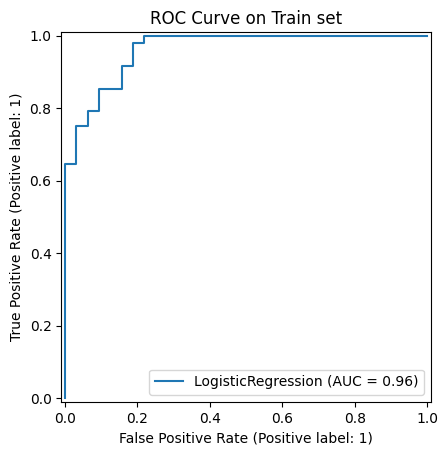

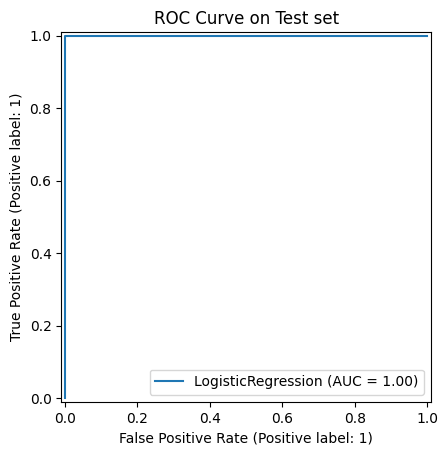

In [74]:
# Visualize ROC curves
_ , ax = plt.subplots() # Get subplot from matplotlib
ax.set(title="ROC Curve on Train set") # Set a title that we will add into ConfusionMatrixDisplay
RocCurveDisplay.from_estimator(rl, X_train, Y_train, ax=ax) # RocCurveDisplay from sklearn
plt.show()

_ , ax = plt.subplots() # Get subplot from matplotlib
ax.set(title="ROC Curve on Test set") # Set a title that we will add into ConfusionMatrixDisplay
RocCurveDisplay.from_estimator(rl, X_test, Y_test, ax=ax) # RocCurveDisplay from sklearn
plt.show()


**The area under the curves is quite close to 1. This means that the model is robust as it does not depend on the choice of the threshold used in the logistic regression.**

15. Create a DataFrame named predictions_df_train that contains the following values on train set:
* explanatory variables "Col_1" and "Col_2"
* the target variable Y
* the predictions Y_pred 
* the estimated probabilites from the classifier. 

Sort the values according to the probabilities (in ascending order).

In [75]:
predictions_df_train = pd.DataFrame(X_train, columns = ['Col_1', 'Col_2'])
predictions_df_train["Y"] = Y_train.tolist()
predictions_df_train["Y_pred"] = Y_train_pred.tolist()
predictions_df_train["Proba"] = Y_train_proba[:,1]
predictions_df_train = predictions_df_train.sort_values(by="Proba")
predictions_df_train.head()


,Col_1,Col_2,Y,Y_pred,Proba
66,-1.771519,-1.210111,0,0,0.005923
44,-1.649222,-1.241779,0,0,0.007231
59,-1.782960,-0.903145,0,0,0.010260
45,-0.506668,-1.658564,0,0,0.036487
8,-1.558775,-0.321138,0,0,0.047638


16. Plot the probabilities as a function of the variables "Col_1" and "Col_2". Change the marker color according to the values of "Y_pred".

In [76]:
# Visualize the model
# Visualize predictions on training Set
fig = px.scatter_3d(predictions_df_train, x = 'Col_1', y = 'Col_2', z = 'Proba', title = "training set", color = 'Y_pred')
fig.show()


17. Use the library mlxtend to plot the decision boundary of the model. You might need to install it before : 
```python
!pip install mlxtend
```
This documentation page might help you 😉 : http://rasbt.github.io/mlxtend/api_subpackages/mlxtend.plotting/

In [77]:
!pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 16.7 MB/s  0:00:00


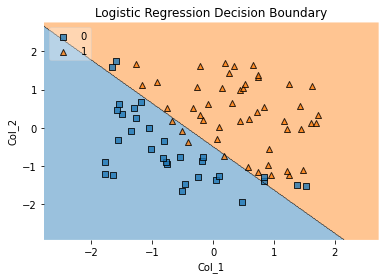

In [ ]:
from mlxtend.plotting import plot_decision_regions


X = predictions_df_train.iloc[:,:2].values
Y = predictions_df_train.loc[:,"Y"].values

# Plotting decision regions
plot_decision_regions(X, Y, clf=rl, legend=2)

# Adding axes annotations
plt.xlabel('Col_1')
plt.ylabel('Col_2')
plt.title('Logistic Regression Decision Boundary')
plt.show()
